In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
pd.set_option('display.max_columns', None)

In [2]:
train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")

C:\Users\siavash\AppData\Local\Temp\ipykernel_12152\2005772569.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


In [3]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [6]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [7]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [8]:
train['Date'] = pd.to_datetime(train['Date'])

In [9]:
train['Date'].dtype

dtype('<M8[ns]')

In [10]:
train['Date'].min()

Timestamp('2013-01-01 00:00:00')

In [11]:
train['Date'].max()

Timestamp('2015-07-31 00:00:00')

In [12]:
# Create time-based features for forecasting
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Week'] = train['Date'].dt.isocalendar().week
train['DayOfYear'] = train['Date'].dt.dayofyear
train['IsWeekend'] = train['DayOfWeek'].apply(lambda x: 1 if x in [6,7] else 0)

In [13]:
# Fill missing CompetitionDistance with median
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

In [14]:
# Missingness indicators for competition timing variables 
store['CompetitionOpenSinceMonth_missing'] = store['CompetitionOpenSinceMonth'].isnull().astype(int)
store['CompetitionOpenSinceYear_missing'] = store['CompetitionOpenSinceYear'].isnull().astype(int)

In [15]:
# Fill missing competition start dates with 0
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0)

In [16]:
# Missingness Indicator Features for promo2 related variables
store['Promo2SinceWeek_missing'] = store['Promo2SinceWeek'].isnull().astype(int)
store['Promo2SinceYear_missing'] = store['Promo2SinceYear'].isnull().astype(int)
store['PromoInterval_missing'] = store['PromoInterval'].isnull().astype(int)

In [17]:
# Fill missing Promo2 Timing Variables with 0 since there is no promo2 for these
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0)
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0)
store['PromoInterval'] = store['PromoInterval'].fillna("None")

In [18]:
# Competition Duration Feature
# Create competition start date column
store['CompetitionStartDate'] = pd.to_datetime(
    dict(
        year=store['CompetitionOpenSinceYear'].replace(0, np.nan),
        month=store['CompetitionOpenSinceMonth'].replace(0, np.nan),
        day=1
    ),
    errors='coerce'
)

In [19]:
# Merge Sales Training Data with Store Data 
df = train.merge(store, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Week,DayOfYear,IsWeekend,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionOpenSinceMonth_missing,CompetitionOpenSinceYear_missing,Promo2SinceWeek_missing,Promo2SinceYear_missing,PromoInterval_missing,CompetitionStartDate
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,212,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None,0,0,1,1,1,2008-09-01
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,212,0,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",0,0,0,0,0,2007-11-01
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,212,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",0,0,0,0,0,2006-12-01
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,212,0,c,c,620.0,9.0,2009.0,0,0.0,0.0,None,0,0,1,1,1,2009-09-01
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,212,0,a,a,29910.0,4.0,2015.0,0,0.0,0.0,None,0,0,1,1,1,2015-04-01


In [20]:
# Competition duration in months (approximation using 30 days)
df['CompetitionDuration'] = (
    (df['Date'] - df['CompetitionStartDate']).dt.days / 30
).clip(lower=0)

In [21]:
# Drop Redundant Competition Features 
drop_cols = [
    'CompetitionOpenSinceYear',
    'CompetitionOpenSinceMonth',
    'CompetitionStartDate'
]

df.drop(columns=[col for col in drop_cols if col in df.columns],
        inplace=True)

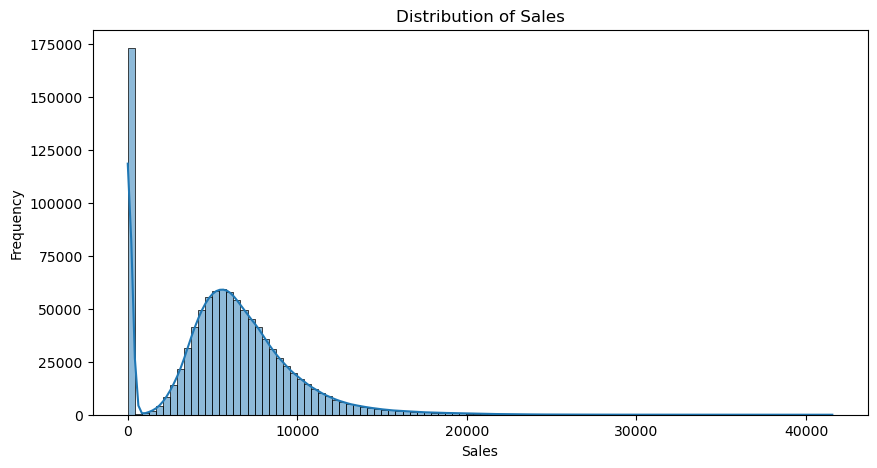

In [22]:
# Check sales distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Sales'], bins=100, kde=True)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")
plt.show()

In [23]:
df['Sales'].skew()

np.float64(0.6414596158103787)

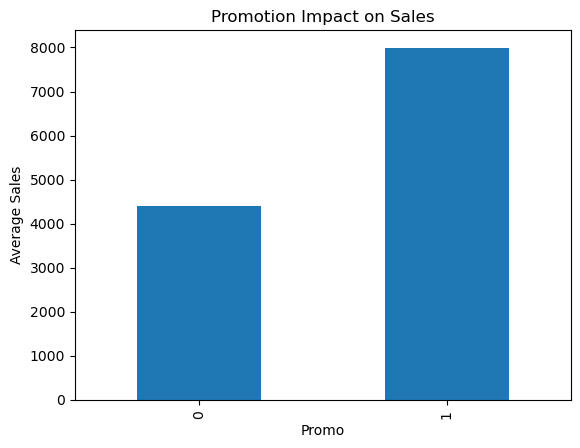

In [24]:
# Sales comparison based on Promo vs No Promo
df.groupby('Promo')['Sales'].mean().plot(kind='bar')
plt.ylabel("Average Sales")
plt.title("Promotion Impact on Sales")
plt.show()

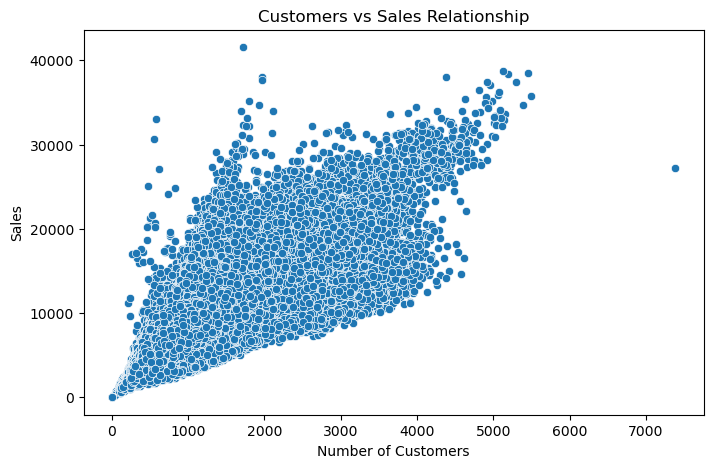

In [25]:
# Customers vs Sales Relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Customers'], y=df['Sales'])
plt.xlabel("Number of Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales Relationship")
plt.show()

In [26]:
# Correlation between Customers and Sales 
corr_value = df[['Customers','Sales']].corr().iloc[0,1]
print(corr_value)

0.8947107733016734


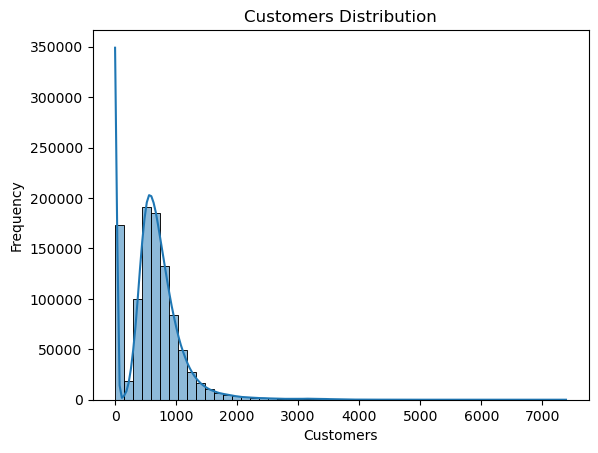

In [27]:
# Customers Distribution 
sns.histplot(df['Customers'], bins=50, kde=True)
plt.xlabel("Customers")
plt.ylabel("Frequency")
plt.title("Customers Distribution")
plt.show()

In [28]:
df['Customers'].skew()

np.float64(1.5986502899508919)

In [29]:
# Validation period = last 6 weeks of dataset
cutoff_date = df['Date'].max() - pd.Timedelta(weeks=6)
train_df = df[df['Date'] < cutoff_date]
val_df = df[df['Date'] >= cutoff_date]

In [30]:
print("Train range:")
print(train_df['Date'].min(), train_df['Date'].max())

print("\nValidation range:")
print(val_df['Date'].min(), val_df['Date'].max())

Train range:
2013-01-01 00:00:00 2015-06-18 00:00:00

Validation range:
2015-06-19 00:00:00 2015-07-31 00:00:00


In [31]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Week,DayOfYear,IsWeekend,StoreType,Assortment,CompetitionDistance,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionOpenSinceMonth_missing,CompetitionOpenSinceYear_missing,Promo2SinceWeek_missing,Promo2SinceYear_missing,PromoInterval_missing,CompetitionDuration
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,212,0,c,a,1270.0,0,0.0,0.0,None,0,0,1,1,1,84.133333
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,212,0,a,a,570.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",0,0,0,0,0,94.300000
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,212,0,a,a,14130.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",0,0,0,0,0,105.466667
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,212,0,c,c,620.0,0,0.0,0.0,None,0,0,1,1,1,71.966667
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,212,0,a,a,29910.0,0,0.0,0.0,None,0,0,1,1,1,4.033333


In [32]:
y_train = train_df['Sales']
y_val = val_df['Sales']

In [33]:
# Drop target and non-feature columns
drop_cols = ['Sales', 'Date']
X_train = train_df.drop(columns=drop_cols)
X_val = val_df.drop(columns=drop_cols)

y_train = train_df['Sales']
y_val = val_df['Sales']

In [34]:
print(X_train.shape)
print(X_val.shape)
print(X_train.columns.equals(X_val.columns))

(969264, 25)
(47945, 25)
True


In [35]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)

# Align columns after encoding
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

In [36]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [37]:
# Remove special characters from feature names
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [38]:
# fitting LighGBM model
lgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='rmse'
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.154767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1427
[LightGBM] [Info] Number of data points in the train set: 969264, number of used features: 33
[LightGBM] [Info] Start training from score 5760.668789


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
              random_state=42, subsample=0.8)

In [39]:
val_pred = lgbm_model.predict(X_val)

In [40]:
rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 716.0813066063293


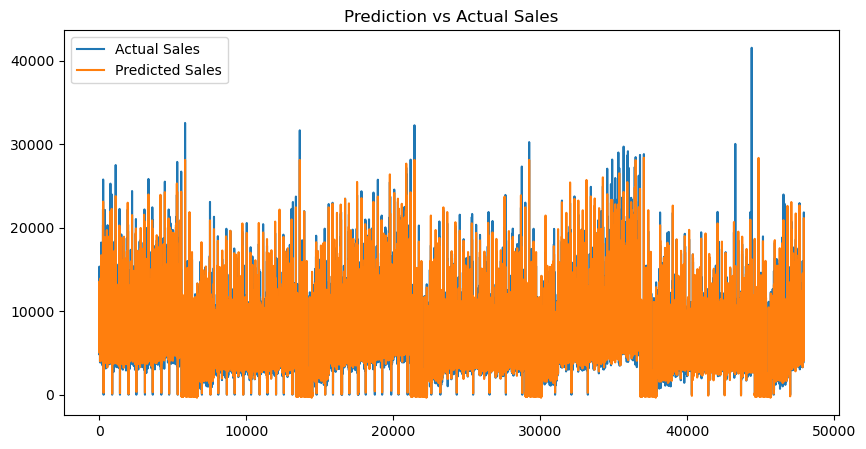

In [41]:
plt.figure(figsize=(10,5))
plt.plot(y_val.values, label="Actual Sales")
plt.plot(val_pred, label="Predicted Sales")
plt.legend()
plt.title("Prediction vs Actual Sales")
plt.show()

In [42]:
# Combine train and validation dataset
final_train_X = pd.concat([X_train, X_val])
final_train_y = pd.concat([y_train, y_val])

# Retrain model
lgbm_model.fit(final_train_X, final_train_y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.139419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1427
[LightGBM] [Info] Number of data points in the train set: 1017209, number of used features: 33
[LightGBM] [Info] Start training from score 5773.818972


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=500,
              random_state=42, subsample=0.8)

In [43]:
test_df = pd.read_csv("test.csv")

In [44]:
# Merge store information into test data
test_df = test_df.merge(store, on="Store", how="left")

In [45]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionOpenSinceMonth_missing,CompetitionOpenSinceYear_missing,Promo2SinceWeek_missing,Promo2SinceYear_missing,PromoInterval_missing,CompetitionStartDate
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None,0,0,1,1,1,2008-09-01
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",0,0,0,0,0,2006-12-01
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,0.0,0.0,None,0,0,1,1,1,2013-04-01
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,0.0,0.0,None,0,0,1,1,1,2014-10-01
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,0.0,0.0,None,0,0,1,1,1,2000-08-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",0,0,0,0,0,2014-06-01
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,0.0,0.0,None,0,0,1,1,1,2006-04-01
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,0.0,0.0,0,0.0,0.0,None,1,1,1,1,1,NaT
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,0.0,0.0,0,0.0,0.0,None,1,1,1,1,1,NaT


In [46]:
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df['Year'] = test_df['Date'].dt.year
test_df['Month'] = test_df['Date'].dt.month
test_df['Day'] = test_df['Date'].dt.day

In [47]:
# Calculate competition duration in months (approx. 30 days per month)
test_df['CompetitionDuration'] = (
    (test_df['Date'] - test_df['CompetitionStartDate']).dt.days / 30
).clip(lower=0)

In [48]:
# Drop redundant competition columns from test dataset
test_df.drop(columns=[
    'CompetitionOpenSinceYear',
    'CompetitionOpenSinceMonth',
    'CompetitionStartDate',
    'Date'
], inplace=True)

In [49]:
# Align test features with training features (best practice)
test_features = test_df.reindex(columns=X_train.columns, fill_value=0)

# Verify alignment
print(X_train.columns.equals(test_features.columns))

True


In [50]:
test_pred = lgbm_model.predict(test_features)

In [51]:
'''
# Create prediction dataframe with title "prediction"
prediction = pd.DataFrame({
    "Id": test_df["Id"],
    "Sales": test_pred
})

# Save file with name prediction.csv
prediction.to_csv("prediction.csv", index=False)
'''

'\n# Create prediction dataframe with title "prediction"\nprediction = pd.DataFrame({\n    "Id": test_df["Id"],\n    "Sales": test_pred\n})\n\n# Save file with name prediction.csv\nprediction.to_csv("prediction.csv", index=False)\n'

In [55]:
'''
# Reload original test dataset
test_df = pd.read_csv("test.csv")

# Merge store data again (if you did merging earlier)
test_df = test_df.merge(store, on='Store', how='left')

# Convert Date column
test_df['Date'] = pd.to_datetime(test_df['Date'])
'''

In [57]:
# Create dashboard dataset using important analysis columns
dashboard_df = test_df[[
    'Date',
    'Store',
    'Open',
    'Promo',
    'StoreType',
    'Assortment'
]].copy()

# Add model prediction output
dashboard_df["PredictedSales"] = test_pred

# Save dataset for Power BI dashboard
dashboard_df.to_csv("dashboard_data.csv", index=False)